In [1]:
import pandas as pd
import numpy as np
import math

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

/home/tyumen/saiga_8b/saiga_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('ru_cefr_short.csv')  
df

,fragment,textbook-assigned cefr level
0,"Весной, летом и осенью почти каждую субботу он...",1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1
2,На каждой двери красные плакаты и красные фона...,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1
...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6
7320,Mapillary использует программное обеспечение д...,6


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_name = "ai-forever/ruRoberta-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name).to('cpu')

print(f"Модель инициализирована")

Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ruRoberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована


In [4]:
def get_bert_embeddings(texts, batch_size=16):
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors='pt'
        ).to('cpu')

        with torch.no_grad():
            model_output = bert_model(**encoded)

        batch_embeddings = model_output.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(batch_embeddings)

    return np.vstack(embeddings)

texts = df['fragment'].tolist()
bert_embeddings = get_bert_embeddings(texts)
print(f"Размер BERT эмбеддингов: {bert_embeddings.shape}")

Размер BERT эмбеддингов: (7322, 1024)


# Классификация

In [5]:
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    # ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Classifier', CatBoostClassifier(random_state=42, verbose=False)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Naive Bayes', GaussianNB()),
    # ('XGBoost', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1, n_estimators=100))
]

In [6]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

## Классификация. С1 и С2 раздельно

In [7]:
y = df['textbook-assigned cefr level'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    bert_embeddings, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [8]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [9]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,0,Logistic Regression,0.582935,0.582935,0.560190,0.582006,0.554266
1,4,SVM,0.582253,0.582253,0.492113,0.571033,0.554949
2,3,CatBoost Classifier,0.578840,0.578840,0.492428,0.569704,0.564505
3,7,LightGBM,0.565870,0.565870,0.485870,0.555744,0.575427
4,5,K-Nearest Neighbors,0.543345,0.543345,0.509468,0.537559,0.682594
5,2,Random Forest,0.500341,0.500341,0.400614,0.479533,0.691468
6,1,Decision Tree,0.312628,0.312628,0.270455,0.312523,1.080546
7,6,Naive Bayes,0.174061,0.174061,0.136463,0.110756,1.817747


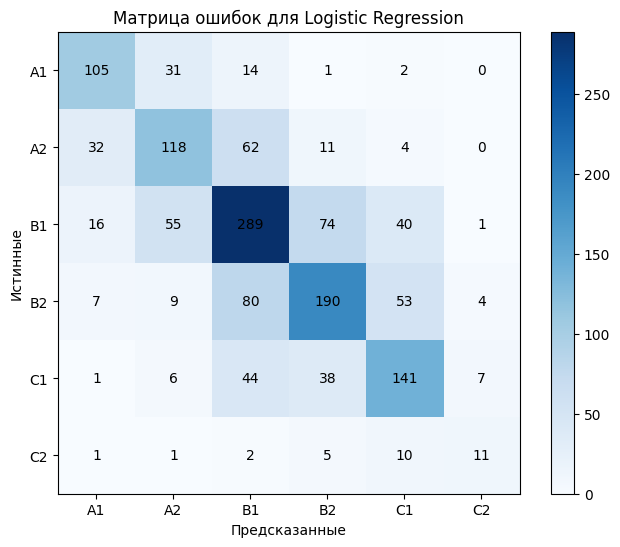

In [10]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

## Классификация. С1 и С2 вместе

In [11]:
y = df['textbook-assigned cefr level'].replace(6, 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    bert_embeddings, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [12]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [13]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,CatBoost Classifier,0.602048,0.602048,0.598694,0.598297,0.517406
1,4,SVM,0.596587,0.596587,0.586992,0.590506,0.524915
2,0,Logistic Regression,0.578840,0.578840,0.584027,0.578041,0.550853
3,7,LightGBM,0.566553,0.566553,0.557652,0.561909,0.570648
4,5,K-Nearest Neighbors,0.553584,0.553584,0.546378,0.550255,0.656655
5,2,Random Forest,0.509898,0.509898,0.485204,0.496867,0.665529
6,1,Decision Tree,0.340614,0.340614,0.333757,0.341445,1.034812
7,6,Naive Bayes,0.181570,0.181570,0.138190,0.117768,1.777474


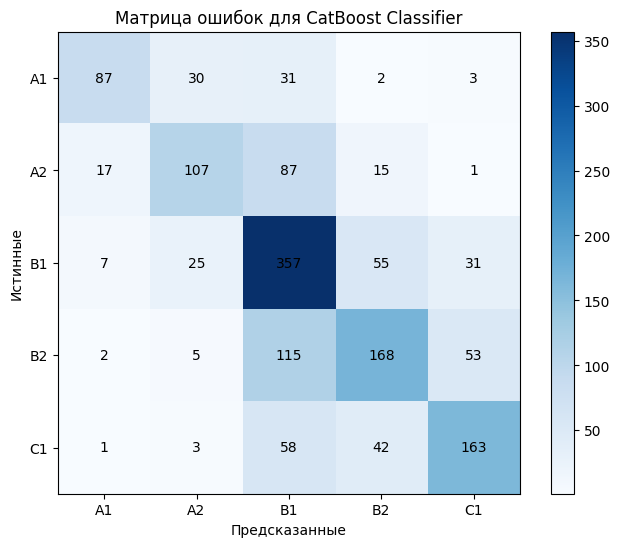

In [14]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

# Регрессия

In [15]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    # ('Random Forest', RandomForestRegressor(random_state=42, max_depth=5)),
    # ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Regressor', CatBoostRegressor(random_state=42, verbose=False)),
    ('SVM', SVR()),
    ('K-Nearest Neighbors', KNeighborsRegressor()),
    ('Naive Bayes', GaussianNB()),
    # ('XGBoost', XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMRegressor(random_state=42, verbose=-1, n_estimators=100))
]

## Регрессия. С1 и С2 раздельно

In [16]:
y = df['textbook-assigned cefr level'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    bert_embeddings, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [17]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, round_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if round_type == 'math':
        y_pred = [round(i) for i in y_pred]
    elif round_type == 'ceil':
        y_pred = [math.ceil(i) for i in y_pred] 
    elif round_type == 'floor':
        y_pred = [math.floor(i) for i in y_pred] 

    y_pred = np.clip(y_pred, 1, 6).tolist()

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

### Математическое округление

In [18]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'math')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [19]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,SVM,0.518771,0.518771,0.417562,0.504864,0.549488
1,2,CatBoost Regressor,0.501024,0.501024,0.407326,0.490920,0.571331
2,4,K-Nearest Neighbors,0.484642,0.484642,0.396731,0.473065,0.621843
3,0,Linear Regression,0.467577,0.467577,0.409598,0.467177,0.615700
4,6,LightGBM,0.475085,0.475085,0.370670,0.457756,0.603413
5,1,Decision Tree,0.369966,0.369966,0.320651,0.370591,0.954949
6,5,Naive Bayes,0.174061,0.174061,0.136463,0.110756,1.817747


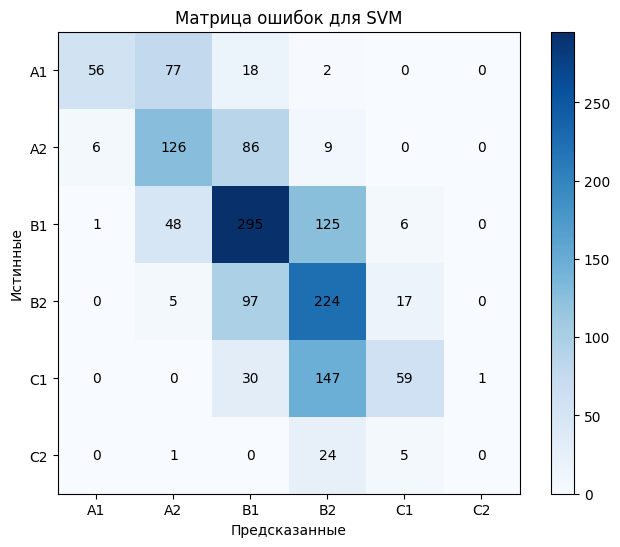

In [20]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вверх

In [21]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'ceil')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [22]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,K-Nearest Neighbors,0.447782,0.447782,0.369037,0.434017,0.663481
1,3,SVM,0.405461,0.405461,0.320161,0.380149,0.704437
2,1,Decision Tree,0.369966,0.369966,0.320651,0.370591,0.954949
3,2,CatBoost Regressor,0.390444,0.390444,0.290977,0.361958,0.724915
4,0,Linear Regression,0.359727,0.359727,0.305402,0.357080,0.769283
5,6,LightGBM,0.377474,0.377474,0.286464,0.342001,0.756997
6,5,Naive Bayes,0.174061,0.174061,0.136463,0.110756,1.817747


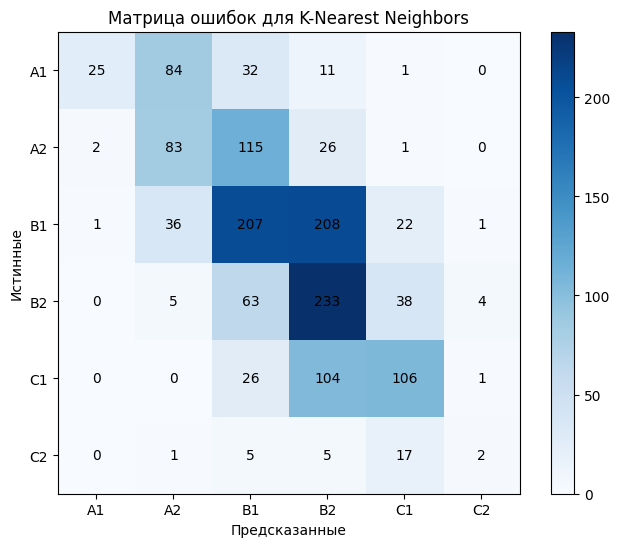

In [23]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вниз

In [24]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'floor')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [25]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,0,Linear Regression,0.421160,0.421160,0.361579,0.407364,0.722867
1,4,K-Nearest Neighbors,0.417065,0.417065,0.326800,0.379698,0.754266
2,3,SVM,0.415700,0.415700,0.321844,0.376485,0.703754
3,2,CatBoost Regressor,0.410239,0.410239,0.315541,0.372222,0.709898
4,1,Decision Tree,0.369966,0.369966,0.320651,0.370591,0.954949
5,6,LightGBM,0.406826,0.406826,0.307486,0.364278,0.718089
6,5,Naive Bayes,0.174061,0.174061,0.136463,0.110756,1.817747


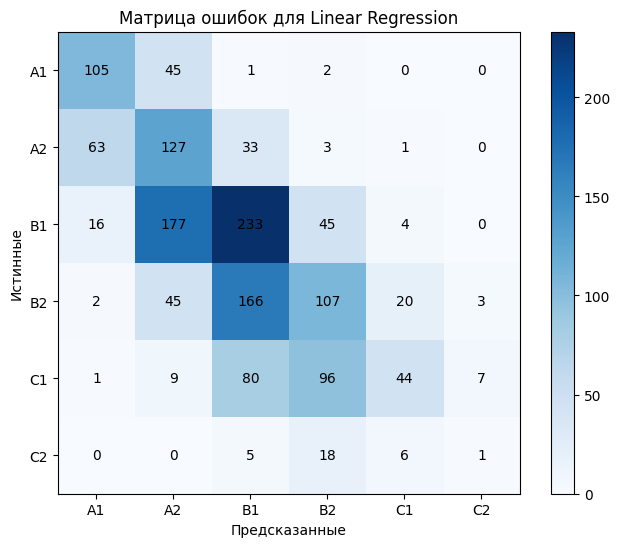

In [26]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

## Регрессия. С1 и С2 вместе

In [27]:
y = df['textbook-assigned cefr level'].replace(6, 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    bert_embeddings, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [28]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, round_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if round_type == 'math':
        y_pred = [round(i) for i in y_pred]
    elif round_type == 'ceil':
        y_pred = [math.ceil(i) for i in y_pred] 
    elif round_type == 'floor':
        y_pred = [math.floor(i) for i in y_pred] 

    y_pred = np.clip(y_pred, 1, 5).tolist()

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

### Математическое округление

In [29]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'math')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [30]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,SVM,0.526280,0.526280,0.503855,0.515600,0.526280
1,2,CatBoost Regressor,0.496246,0.496246,0.466444,0.484093,0.553584
2,0,Linear Regression,0.482594,0.482594,0.476970,0.482195,0.580205
3,4,K-Nearest Neighbors,0.486689,0.486689,0.471723,0.476127,0.612969
4,6,LightGBM,0.470990,0.470990,0.432608,0.454125,0.593174
5,1,Decision Tree,0.367918,0.367918,0.366914,0.367315,0.957679
6,5,Naive Bayes,0.181570,0.181570,0.138190,0.117768,1.777474


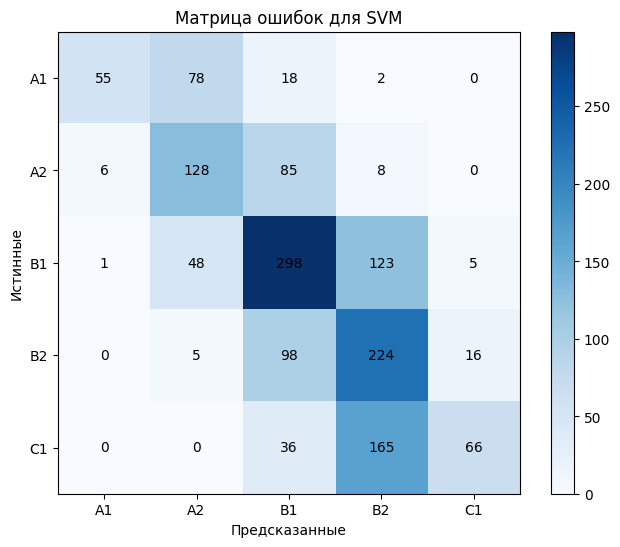

In [31]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вверх

In [32]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'ceil')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [33]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,K-Nearest Neighbors,0.457338,0.457338,0.429967,0.448373,0.636860
1,3,SVM,0.423208,0.423208,0.377971,0.401118,0.674403
2,2,CatBoost Regressor,0.419795,0.419795,0.373909,0.396708,0.676451
3,0,Linear Regression,0.409556,0.409556,0.375221,0.395777,0.691468
4,6,LightGBM,0.408191,0.408191,0.356941,0.382414,0.707850
5,1,Decision Tree,0.367918,0.367918,0.366914,0.367315,0.957679
6,5,Naive Bayes,0.181570,0.181570,0.138190,0.117768,1.777474


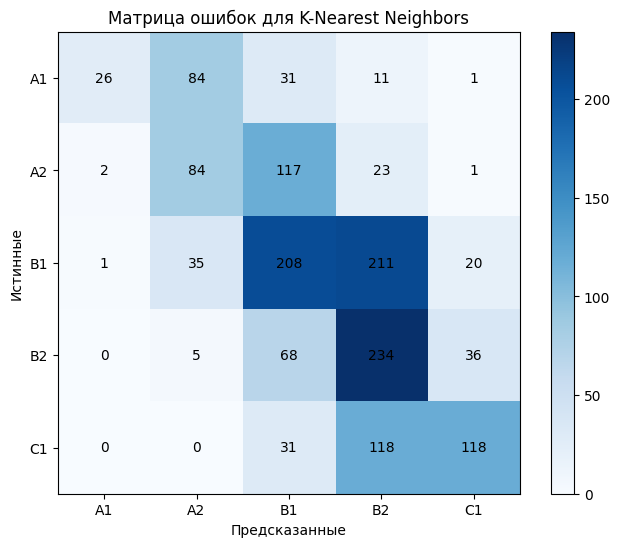

In [34]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вниз

In [35]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'floor')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [36]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,0,Linear Regression,0.430034,0.430034,0.432694,0.418026,0.693515
1,3,SVM,0.415017,0.415017,0.385787,0.376404,0.686007
2,4,K-Nearest Neighbors,0.416382,0.416382,0.385075,0.375239,0.744027
3,1,Decision Tree,0.367918,0.367918,0.366914,0.367315,0.957679
4,2,CatBoost Regressor,0.404096,0.404096,0.369425,0.359378,0.706485
5,6,LightGBM,0.393174,0.393174,0.351830,0.348739,0.718089
6,5,Naive Bayes,0.181570,0.181570,0.138190,0.117768,1.777474


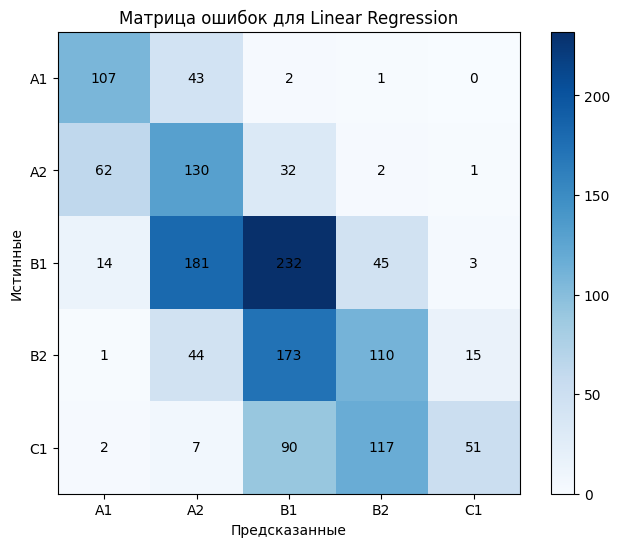

In [37]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()